# VAE Easy Task — Basic VAE Clustering

Run the **Easy Task** experiment:
- FMA Small metadata (pre-extracted features)
- Simulated Bangla audio features
- MLP-VAE training
- KMeans clustering vs PCA+KMeans baseline
- t-SNE / UMAP visualisation
- Silhouette + Calinski-Harabasz metrics

> All heavy lifting lives in  and . This notebook drives the experiment interactively.

## 0. Setup

In [1]:
import sys
from pathlib import Path

# Make project root importable (works from notebooks/ sub-directory)
PROJECT_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

Project root: /Users/israt/Codes/VAE-music


In [2]:
import warnings
import numpy as np
import torch
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import umap as umap_lib

from config.config import (
    BANGLA_QUERIES, BETA_DEFAULT, EPOCHS, HIDDEN_DIMS,
    KMEANS_NINIT, LATENT_DIM, LR, BATCH_SIZE, FMA_METADATA_URL,
    LANG_COLORS, LANG_MARKERS,
)
from src.data.fma import download_fma_metadata, load_fma
from src.models.mlp_vae import MLPVAE
from src.training.trainer import extract_latent, train_model
from src.clustering.engine import elbow_analysis
from src.visualization.plots import (
    plot_dataset_distribution, plot_training_curves, plot_elbow,
    plot_tsne_umap, plot_cluster_composition, plot_language_separation,
    plot_metrics_comparison,
)

warnings.filterwarnings("ignore")
np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RESULTS = PROJECT_ROOT / "results" / "easy"
RESULTS.mkdir(parents=True, exist_ok=True)
print("Device:", DEVICE)

/Users/israt/Codes/VAE-music/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Device: cpu


## 1. Download FMA Metadata

In [3]:
FMA_DIR = PROJECT_ROOT / "data" / "fma" / "fma_metadata"
download_fma_metadata(FMA_DIR, FMA_METADATA_URL)

  [FMA] Metadata already present at /Users/israt/Codes/VAE-music/data/fma/fma_metadata


## 2. Load English Features + Simulate Bangla

In [4]:
X_en, y_en = load_fma(FMA_DIR)
lang_en = np.array(["English"] * len(X_en))
X_en = np.nan_to_num(X_en)
print(f"English: {X_en.shape}")

  [FMA] Loaded: (10000, 57) | Genres: ['Blues', 'Classical', 'Country', 'Easy Listening', 'Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Jazz', 'Old-Time / Historic', 'Pop', 'Rock', 'Soul-RnB', 'Spoken']
English: (10000, 57)


In [5]:
# Simulate Bangla features (genre-realistic Gaussian)
from scripts.run_easy import simulate_bangla_features
en_mean = X_en.mean(axis=0)
en_std  = X_en.std(axis=0) + 1e-8
X_bn, y_bn, lang_bn = simulate_bangla_features(en_mean, en_std)
print(f"Bangla: {X_bn.shape}")

X_raw = np.vstack([X_en, X_bn])
y_labels = np.concatenate([y_en, y_bn])
lang_labels = np.concatenate([lang_en, lang_bn])
X_raw = np.nan_to_num(X_raw)

scaler = StandardScaler()
X_sc = scaler.fit_transform(X_raw)
le_genre = LabelEncoder(); y_genre = le_genre.fit_transform(y_labels)
le_lang  = LabelEncoder(); y_lang  = le_lang.fit_transform(lang_labels)
K = len(le_genre.classes_)
print(f"Total: {X_sc.shape} | Genres: {K}")

Bangla: (100, 57)
Total: (10100, 57) | Genres: 19


## 3. Dataset Distribution

  Saved: /Users/israt/Codes/VAE-music/results/easy/dataset_distribution.png


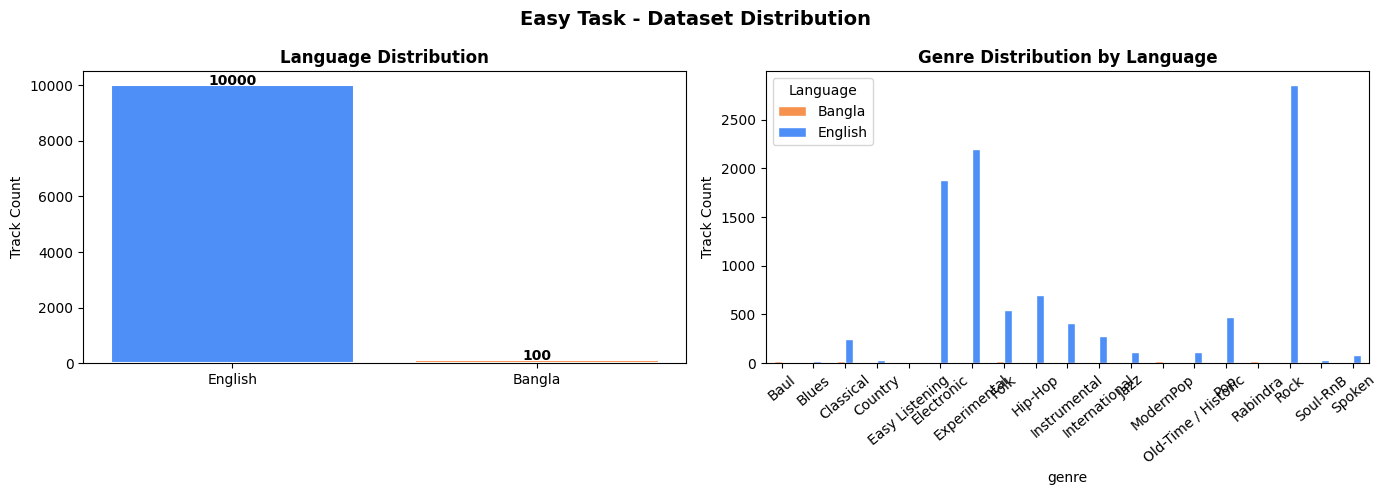

In [6]:
plot_dataset_distribution(y_labels, lang_labels,
    title="Easy Task - Dataset Distribution",
    save_path=RESULTS / "dataset_distribution.png")

## 4. Train MLP-VAE

    Epoch   1/100  loss=54.1285
    Epoch  25/100  loss=34.5068
    Epoch  50/100  loss=33.8458
    Epoch  75/100  loss=33.4228
    Epoch 100/100  loss=33.4396
Best loss: 33.3214
  Saved: /Users/israt/Codes/VAE-music/results/easy/training_curves.png


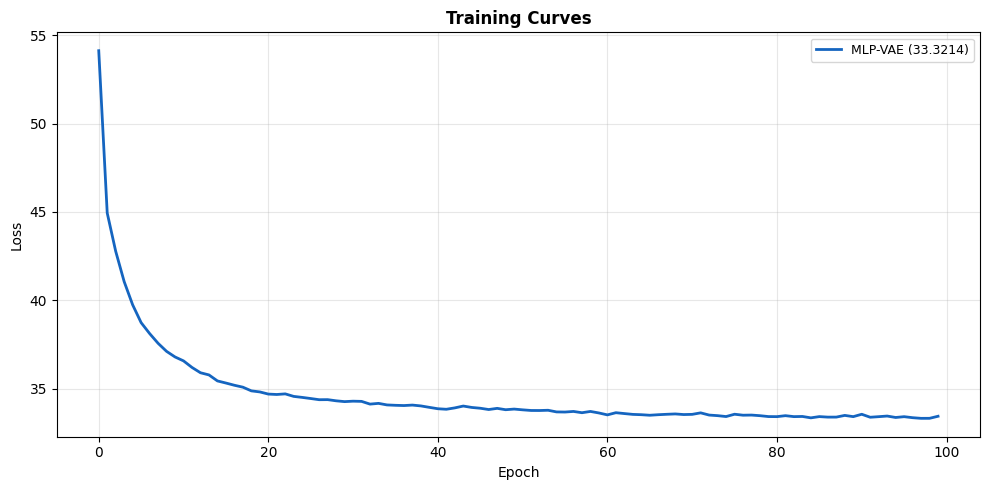

In [7]:
model = MLPVAE(X_sc.shape[1], LATENT_DIM, h=HIDDEN_DIMS)
model, history, best_loss = train_model(
    X_sc, model, model_type="vae", beta=BETA_DEFAULT,
    epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE, device=DEVICE,
)
print(f"Best loss: {best_loss:.4f}")
plot_training_curves(
    {"MLP-VAE": history}, {"MLP-VAE": best_loss}, {"MLP-VAE": "#1565C0"},
    title="Training Curves", save_path=RESULTS / "training_curves.png")

## 5. Extract Latent Space

In [8]:
Z = extract_latent(model, X_sc, device=DEVICE)
print(f"Latent shape: {Z.shape}")

Latent shape: (10100, 32)


## 6. Elbow Method

  Saved: /Users/israt/Codes/VAE-music/results/easy/elbow_method.png


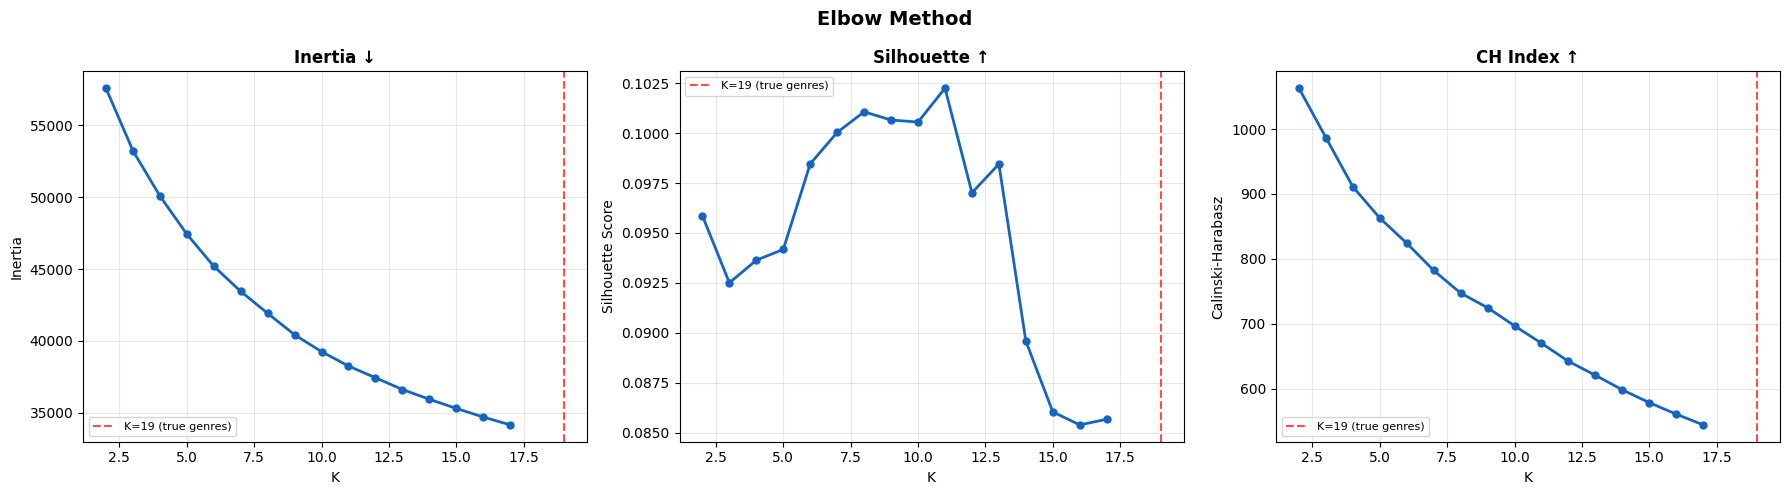

In [9]:
elbow = elbow_analysis(Z, k_range=range(2, 18))
plot_elbow(elbow, true_k=K, save_path=RESULTS / "elbow_method.png")

## 7. Clustering + Baseline

In [10]:
km_vae = KMeans(n_clusters=K, n_init=KMEANS_NINIT, random_state=42)
labels_vae = km_vae.fit_predict(Z)

Z_pca = PCA(n_components=LATENT_DIM, random_state=42).fit_transform(X_sc)
km_pca = KMeans(n_clusters=K, n_init=KMEANS_NINIT, random_state=42)
labels_pca = km_pca.fit_predict(Z_pca)

sil_vae = silhouette_score(Z, labels_vae)
sil_pca = silhouette_score(Z_pca, labels_pca)
ch_vae  = calinski_harabasz_score(Z, labels_vae)
ch_pca  = calinski_harabasz_score(Z_pca, labels_pca)
print(f"VAE Silhouette: {sil_vae:.4f} | PCA: {sil_pca:.4f}")
print(f"VAE CH Index  : {ch_vae:.2f}  | PCA: {ch_pca:.2f}")

VAE Silhouette: 0.0849 | PCA: 0.0392
VAE CH Index  : 513.59  | PCA: 379.46


## 8. t-SNE + UMAP Visualisation

  Saved: /Users/israt/Codes/VAE-music/results/easy/tsne_visualization.png


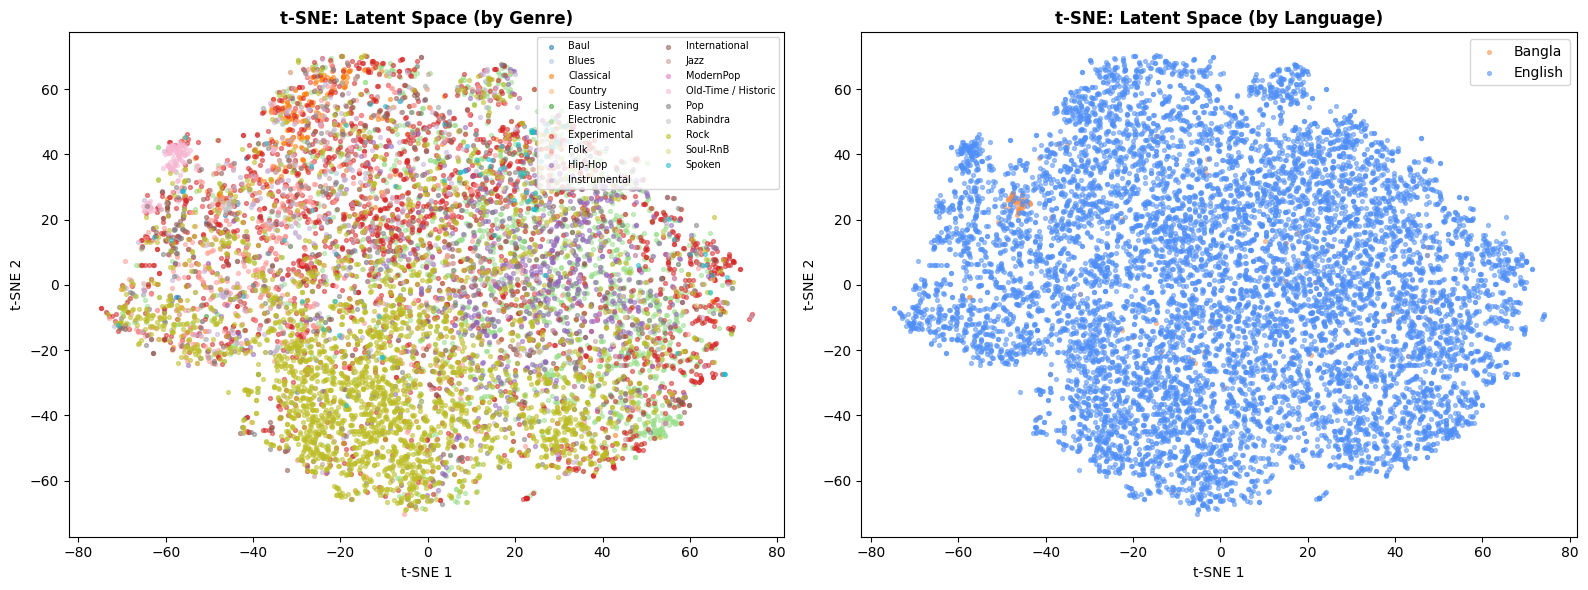

  Saved: /Users/israt/Codes/VAE-music/results/easy/umap_visualization.png


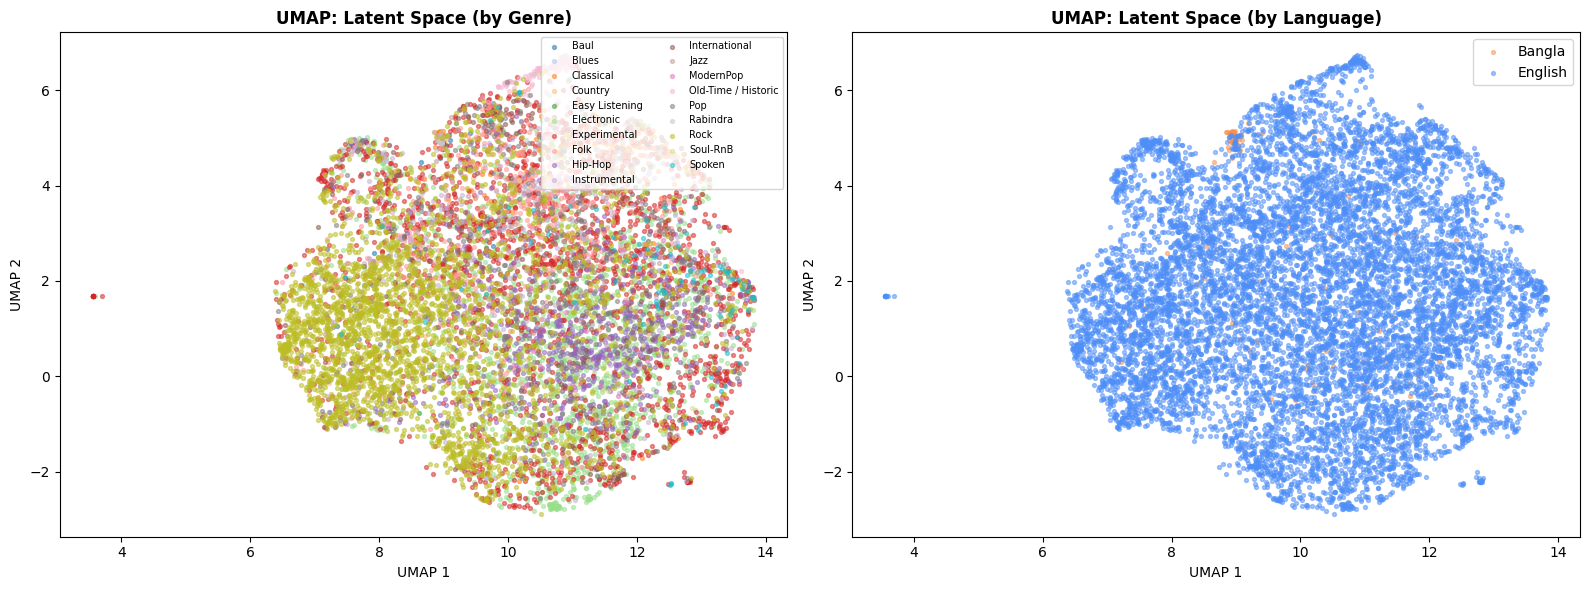

In [11]:
Z_tsne = TSNE(n_components=2, perplexity=40, random_state=42).fit_transform(Z)
plot_tsne_umap(Z_tsne, y_genre, y_lang, list(le_genre.classes_), list(le_lang.classes_),
    projection="t-SNE", save_path=RESULTS / "tsne_visualization.png")

Z_umap = umap_lib.UMAP(n_components=2, n_neighbors=20, min_dist=0.1, random_state=42).fit_transform(Z)
plot_tsne_umap(Z_umap, y_genre, y_lang, list(le_genre.classes_), list(le_lang.classes_),
    projection="UMAP", save_path=RESULTS / "umap_visualization.png")

## 9. Metrics Comparison + Report

  Saved: /Users/israt/Codes/VAE-music/results/easy/metrics_comparison.png


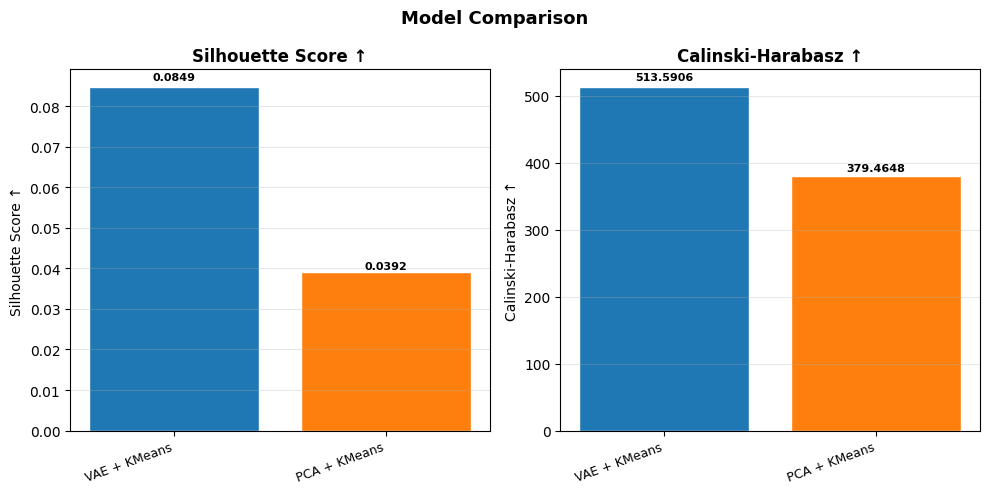

  Saved: /Users/israt/Codes/VAE-music/results/easy/cluster_composition.png


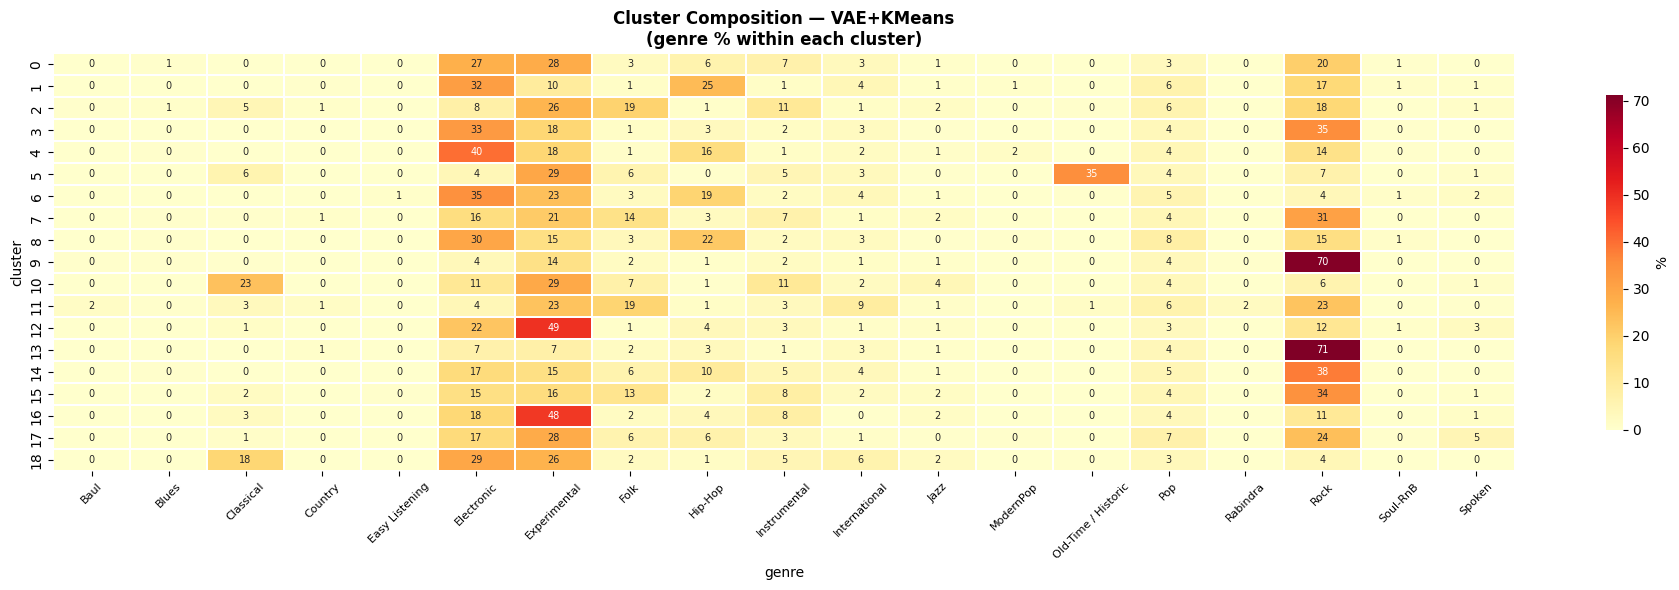

  Saved: /Users/israt/Codes/VAE-music/results/easy/language_separation.png


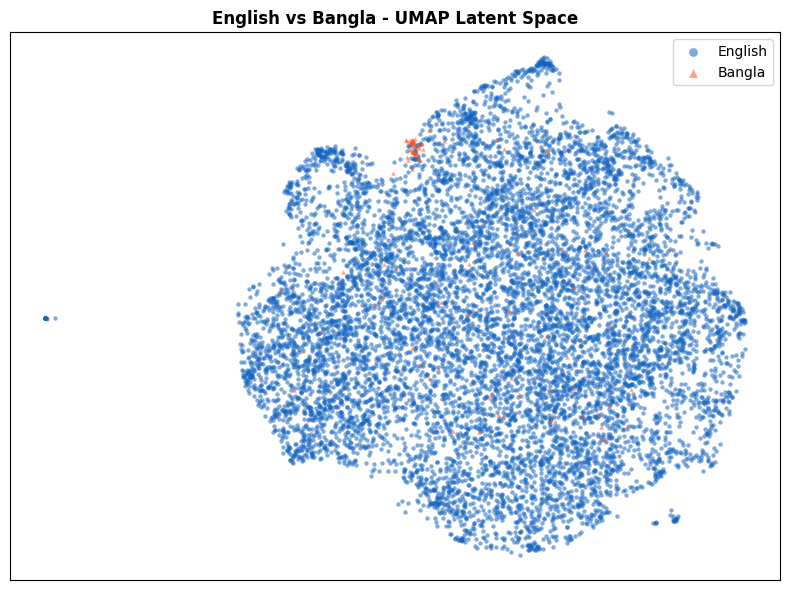

Results saved to: /Users/israt/Codes/VAE-music/results/easy
Winner (Silhouette): VAE
Winner (CH Index)  : VAE


In [15]:
plot_metrics_comparison(
    metrics_dict={
        "VAE + KMeans": {"Silhouette": sil_vae, "Calinski-H": ch_vae},
        "PCA + KMeans": {"Silhouette": sil_pca, "Calinski-H": ch_pca},
    },
    metric_keys=["Silhouette", "Calinski-H"],
    metric_labels=["Silhouette Score ↑", "Calinski-Harabasz ↑"],
    save_path=RESULTS / "metrics_comparison.png",
)

plot_cluster_composition(labels_vae, y_labels, model_name="VAE+KMeans",
    save_path=RESULTS / "cluster_composition.png")

plot_language_separation(Z_umap, lang_labels, LANG_COLORS, LANG_MARKERS,
    save_path=RESULTS / "language_separation.png")

print(f"Results saved to: {RESULTS}")
print(f"Winner (Silhouette): {'VAE' if sil_vae>sil_pca else 'PCA'}")
print(f"Winner (CH Index)  : {'VAE' if ch_vae>ch_pca else 'PCA'}")